<a href="https://colab.research.google.com/github/77mostafaayman77/5G-Resource-Allocation-QoS-Prediction/blob/main/5G_Resource_Allocation_%26_QoS_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Download Data from Kaggle

In [ ]:
import os
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# Download Data from Kaggle
!kaggle datasets download -d omarsobhy14/5g-quality-of-service

# Extract csv file
!unzip 5g-quality-of-service.zip

Dataset URL: https://www.kaggle.com/datasets/omarsobhy14/5g-quality-of-service
License(s): other
100% 4.76k/4.76k [00:00<00:00, 9.58MB/s]

Archive:  5g-quality-of-service.zip
  inflating: Quality of Service 5G.csv  


## Load the Dataset

In [ ]:
import pandas as pd
df = pd.read_csv("/content/Quality of Service 5G.csv")

In [ ]:
df.head()

,Timestamp,User_ID,Application_Type,Signal_Strength,Latency,Required_Bandwidth,Allocated_Bandwidth,Resource_Allocation
0,9/3/2023 10:00,User_1,Video_Call,-75 dBm,30 ms,10 Mbps,15 Mbps,70%
1,9/3/2023 10:00,User_2,Voice_Call,-80 dBm,20 ms,100 Kbps,120 Kbps,80%
2,9/3/2023 10:00,User_3,Streaming,-85 dBm,40 ms,5 Mbps,6 Mbps,75%
3,9/3/2023 10:00,User_4,Emergency_Service,-70 dBm,10 ms,1 Mbps,1.5 Mbps,90%
4,9/3/2023 10:00,User_5,Online_Gaming,-78 dBm,25 ms,2 Mbps,3 Mbps,85%


In [ ]:
df.shape

(400, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Timestamp            400 non-null    object
 1   User_ID              400 non-null    object
 2   Application_Type     400 non-null    object
 3   Signal_Strength      400 non-null    object
 4   Latency              400 non-null    object
 5   Required_Bandwidth   400 non-null    object
 6   Allocated_Bandwidth  400 non-null    object
 7   Resource_Allocation  400 non-null    object
dtypes: object(8)
memory usage: 25.1+ KB


In [ ]:
df.describe()

,Timestamp,User_ID,Application_Type,Signal_Strength,Latency,Required_Bandwidth,Allocated_Bandwidth,Resource_Allocation
count,400,400,400,400,400,400,400,400
unique,7,400,11,84,87,188,194,9
top,9/3/2023 10:01,User_384,Video_Call,-85 dBm,5 ms,0.1 Mbps,0.1 Mbps,70%
freq,60,1,58,9,35,16,16,148


## Data Preprocessing

In [ ]:
df_clean = df.copy()

In [ ]:
df_clean.drop(['Timestamp','User_ID','Allocated_Bandwidth'], axis='columns', inplace=True)
df_clean.head()

,Application_Type,Signal_Strength,Latency,Required_Bandwidth,Resource_Allocation
0,Video_Call,-75 dBm,30 ms,10 Mbps,70%
1,Voice_Call,-80 dBm,20 ms,100 Kbps,80%
2,Streaming,-85 dBm,40 ms,5 Mbps,75%
3,Emergency_Service,-70 dBm,10 ms,1 Mbps,90%
4,Online_Gaming,-78 dBm,25 ms,2 Mbps,85%


In [ ]:
# Unique Values
for column in df_clean.columns:
  print(f"{column}: {df_clean[column].unique()} \n")

Application_Type: ['Video_Call' 'Voice_Call' 'Streaming' 'Emergency_Service' 'Online_Gaming'
 'Background_Download' 'Web_Browsing' 'IoT_Temperature' 'Video_Streaming'
 'File_Download' 'VoIP_Call'] 

Signal_Strength: ['-75 dBm' '-80 dBm' '-85 dBm' '-70 dBm' '-78 dBm' '-90 dBm' '-88 dBm'
 '-95 dBm' '-82 dBm' '-76 dBm' '-79 dBm' '-87 dBm' '-81 dBm' '-74 dBm'
 '-84 dBm' '-69 dBm' '-91 dBm' '-96 dBm' '-83 dBm' '-77 dBm' '-86 dBm'
 '-73 dBm' '-68 dBm' '-92 dBm' '-97 dBm' '-72 dBm' '-67 dBm' '-93 dBm'
 '-98 dBm' '-71 dBm' '-66 dBm' '-94 dBm' '-99 dBm' '-89 dBm' '-65 dBm'
 '-100 dBm' '-64 dBm' '-101 dBm' '-63 dBm' '-102 dBm' '-62 dBm' '-103 dBm'
 '-61 dBm' '-104 dBm' '-60 dBm' '-59 dBm' '-58 dBm' '-57 dBm' '-56 dBm'
 '-55 dBm' '-54 dBm' '-53 dBm' '-52 dBm' '-51 dBm' '-105 dBm' '-50 dBm'
 '-106 dBm' '-107 dBm' '-49 dBm' '-108 dBm' '-109 dBm' '-48 dBm'
 '-110 dBm' '-111 dBm' '-47 dBm' '-112 dBm' '-113 dBm' '-46 dBm'
 '-114 dBm' '-115 dBm' '-45 dBm' '-116 dBm' '-44 dBm' '-117 dBm'
 '-118 dBm' '-4

In [ ]:
# Regex Cleaning
df_clean['Latency'] = df_clean['Latency'].str.extract(r'(\d+)').astype('float') / 1000
df_clean['Signal_Strength'] = df_clean['Signal_Strength'].str.extract(r'(-?\d+)').astype('float')
df_clean['Resource_Allocation'] = df_clean['Resource_Allocation'].str.extract(r'(\d+)').astype(int) / 100
df_clean.head()

,Application_Type,Signal_Strength,Latency,Required_Bandwidth,Resource_Allocation
0,Video_Call,-75.0,0.030,10 Mbps,0.70
1,Voice_Call,-80.0,0.020,100 Kbps,0.80
2,Streaming,-85.0,0.040,5 Mbps,0.75
3,Emergency_Service,-70.0,0.010,1 Mbps,0.90
4,Online_Gaming,-78.0,0.025,2 Mbps,0.85


In [ ]:
def Kbps_to_Mbps(BW):
  BW = BW.split(' ')
  if BW[1] == 'Kbps':
    return float(BW[0]) / 1000
  else:
    return float(BW[0])

# Converting Required_Bandwidth Unit from Kbps to Mbps
df_clean['Required_Bandwidth'] = df_clean['Required_Bandwidth'].apply(Kbps_to_Mbps)
df_clean.rename(columns={'Required_Bandwidth': 'Required_Bandwidth(Mbps)','Signal_Strength': 'Signal_Strength(dBm)','Latency': 'Latency(s)'}, inplace=True)
df_clean.head()

,Application_Type,Signal_Strength(dBm),Latency(s),Required_Bandwidth(Mbps),Resource_Allocation
0,Video_Call,-75.0,0.030,10.0,0.70
1,Voice_Call,-80.0,0.020,0.1,0.80
2,Streaming,-85.0,0.040,5.0,0.75
3,Emergency_Service,-70.0,0.010,1.0,0.90
4,Online_Gaming,-78.0,0.025,2.0,0.85


In [ ]:
# One Hot Encoding
dummies = pd.get_dummies(df_clean.Application_Type, drop_first=True, dtype=int)
dummies.head()

,Emergency_Service,File_Download,IoT_Temperature,Online_Gaming,Streaming,Video_Call,Video_Streaming,VoIP_Call,Voice_Call,Web_Browsing
0,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,1,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0


In [ ]:
df_clean = pd.concat([df_clean,dummies], axis='columns')
df_clean = df_clean.drop('Application_Type', axis='columns')
df_clean.head()

,Signal_Strength(dBm),Latency(s),Required_Bandwidth(Mbps),Resource_Allocation,Emergency_Service,File_Download,IoT_Temperature,Online_Gaming,Streaming,Video_Call,Video_Streaming,VoIP_Call,Voice_Call,Web_Browsing
0,-75.0,0.030,10.0,0.70,0,0,0,0,0,1,0,0,0,0
1,-80.0,0.020,0.1,0.80,0,0,0,0,0,0,0,0,1,0
2,-85.0,0.040,5.0,0.75,0,0,0,0,1,0,0,0,0,0
3,-70.0,0.010,1.0,0.90,1,0,0,0,0,0,0,0,0,0
4,-78.0,0.025,2.0,0.85,0,0,0,1,0,0,0,0,0,0


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Signal_Strength(dBm)      400 non-null    float64
 1   Latency(s)                400 non-null    float64
 2   Required_Bandwidth(Mbps)  400 non-null    float64
 3   Resource_Allocation       400 non-null    float64
 4   Emergency_Service         400 non-null    int64  
 5   File_Download             400 non-null    int64  
 6   IoT_Temperature           400 non-null    int64  
 7   Online_Gaming             400 non-null    int64  
 8   Streaming                 400 non-null    int64  
 9   Video_Call                400 non-null    int64  
 10  Video_Streaming           400 non-null    int64  
 11  VoIP_Call                 400 non-null    int64  
 12  Voice_Call                400 non-null    int64  
 13  Web_Browsing              400 non-null    int64  
dtypes: float64

In [ ]:
df_clean.shape

(400, 14)

In [ ]:
df_clean.describe()

,Signal_Strength(dBm),Latency(s),Required_Bandwidth(Mbps),Resource_Allocation,Emergency_Service,File_Download,IoT_Temperature,Online_Gaming,Streaming,Video_Call,Video_Streaming,VoIP_Call,Voice_Call,Web_Browsing
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.0000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.0000,400.000000
mean,-80.495000,0.033825,3.135512,0.747125,0.117500,0.0025,0.032500,0.112500,0.117500,0.145000,0.117500,0.115000,0.0025,0.120000
std,20.701119,0.021122,3.984097,0.089823,0.322418,0.0500,0.177546,0.316376,0.322418,0.352542,0.322418,0.319421,0.0500,0.325369
min,-123.000000,0.000000,0.000000,0.500000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000
25%,-98.000000,0.021750,0.417500,0.700000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000
50%,-83.000000,0.031000,1.200000,0.700000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000
75%,-64.000000,0.045000,4.100000,0.800000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000
max,-40.000000,0.110000,14.500000,0.900000,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0000,1.000000


In [ ]:
# Correlation Matrix
corr_matrix = df_clean.corr()
corr_matrix["Resource_Allocation"].sort_values(ascending=False)

,Resource_Allocation
Resource_Allocation,1.000000
VoIP_Call,0.609918
Streaming,0.396800
Signal_Strength(dBm),0.303580
Online_Gaming,0.209845
Required_Bandwidth(Mbps),0.072394
Voice_Call,0.029507
Video_Call,-0.010546
File_Download,-0.026298
IoT_Temperature,-0.088420


## Data Visualization

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

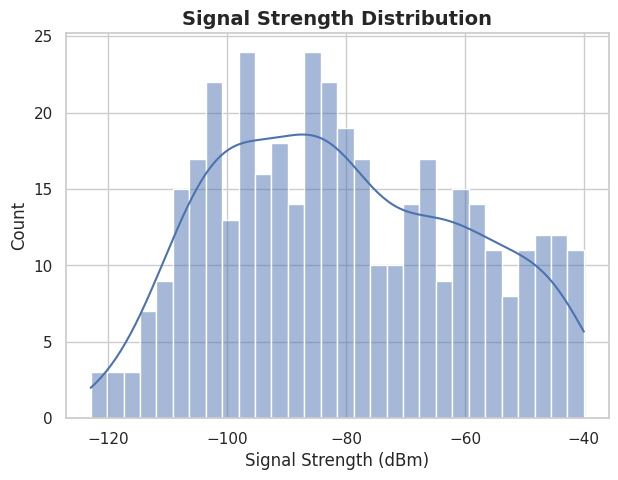

In [ ]:
plt.figure(figsize=(7, 5))
sns.histplot(df_clean['Signal_Strength(dBm)'], bins=30, kde=True)

plt.title('Signal Strength Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Signal Strength (dBm)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

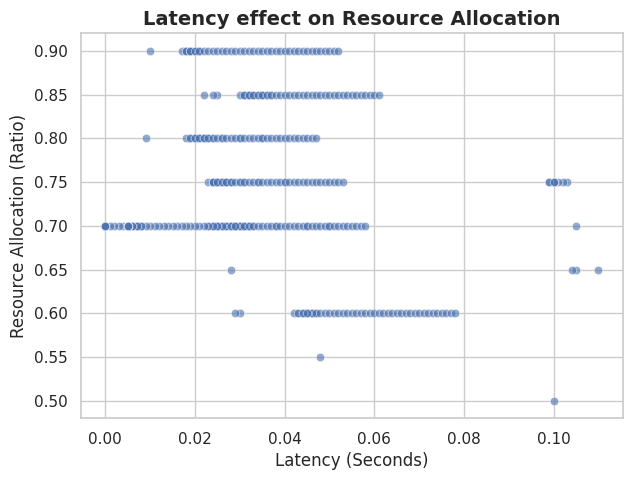

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=df_clean['Latency(s)'], y=df_clean['Resource_Allocation'], alpha=0.6)

plt.title('Latency effect on Resource Allocation', fontsize=14, fontweight='bold')
plt.xlabel('Latency (Seconds)', fontsize=12)
plt.ylabel('Resource Allocation (Ratio)', fontsize=12)
plt.show()

/tmp/ipykernel_6491/2721216823.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Application_Type', y='Resource_Allocation', data=df_plot, palette='Set2')


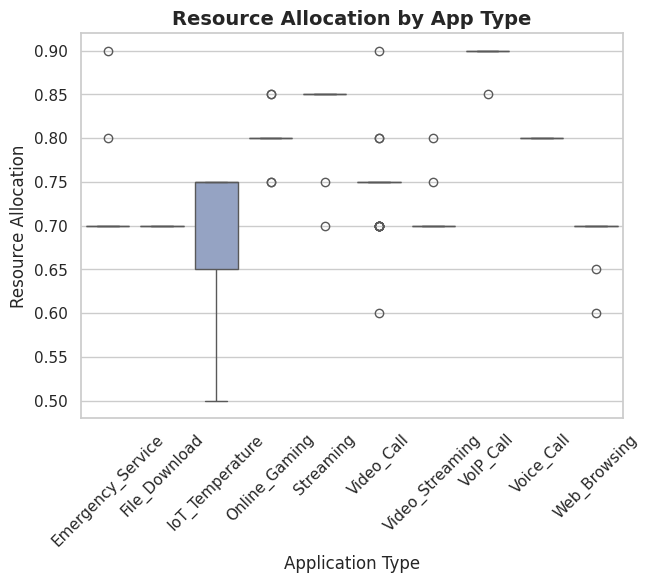

In [ ]:
plt.figure(figsize=(7, 5))

numeric_cols = ['Signal_Strength(dBm)', 'Latency(s)', 'Required_Bandwidth(Mbps)', 'Resource_Allocation']
app_cols = [col for col in df_clean.columns if col not in numeric_cols]

df_plot = df_clean.melt(id_vars=['Resource_Allocation'], value_vars=app_cols,
                        var_name='Application_Type', value_name='Is_Active')

df_plot = df_plot[df_plot['Is_Active'] == 1]

sns.boxplot(x='Application_Type', y='Resource_Allocation', data=df_plot, palette='Set2')

plt.title('Resource Allocation by App Type', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.xlabel('Application Type', fontsize=12)
plt.ylabel('Resource Allocation', fontsize=12)
plt.show()

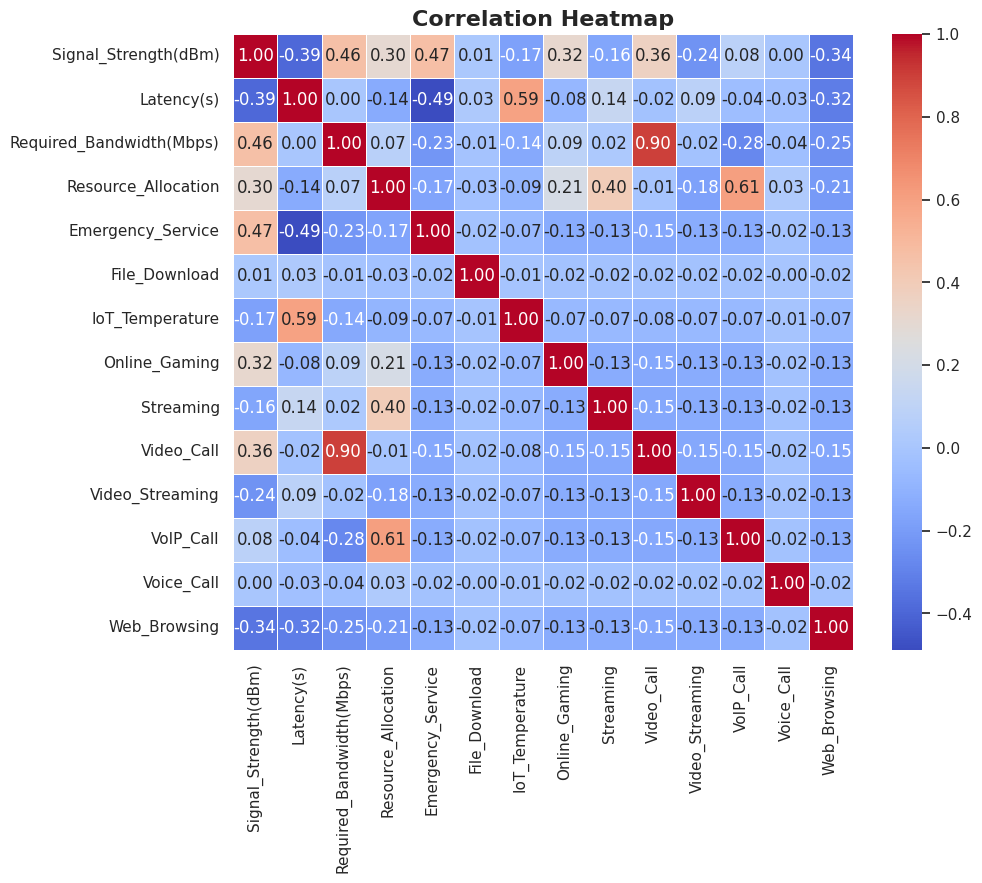

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.show()

# Splitting Data

In [ ]:
X = df_clean.drop('Resource_Allocation',axis='columns')
y = df_clean['Resource_Allocation']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model Architecture

### Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
model_linear = LinearRegression()
model_linear.fit(X_train, y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import root_mean_squared_error , mean_absolute_error , r2_score

y_pred = model_linear.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R-squared Score: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

R-squared Score: 0.8426
Root Mean Squared Error (RMSE): 0.0371
Mean Absolute Error (MAE): 0.0147


In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model_linear, X_train, y_train, cv=5, scoring='r2')

print(f"Scores for each fold: {cv_scores}")
print(f"Average CV R-squared: {cv_scores.mean():.4f}")

Scores for each fold: [0.9591376  0.90126358 0.95566165 0.79368253 0.9636867 ]
Average CV R-squared: 0.9147


## Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = model_rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R-squared Score: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

R-squared Score: 0.8351
Root Mean Squared Error (RMSE): 0.0380
Mean Absolute Error (MAE): 0.0123


In [ ]:
cv_scores = cross_val_score(model_rf, X_train, y_train, cv=5, scoring='r2')

print(f"Scores for each fold: {cv_scores}")
print(f"Average CV R-squared: {cv_scores.mean():.4f}")

Scores for each fold: [0.9677749  0.88140276 0.89982569 0.85816933 0.95475202]
Average CV R-squared: 0.9124


### XGBoost

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor()
model_xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = model_xgb.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R-squared Score: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

R-squared Score: 0.7628
Root Mean Squared Error (RMSE): 0.0455
Mean Absolute Error (MAE): 0.0143


In [ ]:
cv_scores = cross_val_score(model_xgb, X_train, y_train, cv=5, scoring='r2')

print(f"Scores for each fold: {cv_scores}")
print(f"Average CV R-squared: {cv_scores.mean():.4f}")

Scores for each fold: [0.95730146 0.89570242 0.81173792 0.84096062 0.94442279]
Average CV R-squared: 0.8900


### Support Vector Regression

In [ ]:
from sklearn.svm import SVR

model_svr = SVR()
model_svr.fit(X_train,y_train)

SVR()

In [ ]:
y_pred = model_svr.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R-squared Score: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

R-squared Score: 0.4780
Root Mean Squared Error (RMSE): 0.0675
Mean Absolute Error (MAE): 0.0555


In [ ]:
cv_scores = cross_val_score(model_svr, X_train, y_train, cv=5, scoring='r2')

print(f"Scores for each fold: {cv_scores}")
print(f"Average CV R-squared: {cv_scores.mean():.4f}")

Scores for each fold: [0.30308318 0.48680339 0.38947469 0.5004077  0.48612009]
Average CV R-squared: 0.4332


# Fine-Tuning

### Using Random Search to find the best model

In [ ]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV

rf_space = {
    'n_estimators': np.arange(5, 100,10),
    'max_features': [1.0, 'sqrt', 'log2'],
    'max_depth': [None, 10, 20, 30]
    }

random_search = RandomizedSearchCV(
            estimator=model_rf,
            param_distributions=rf_space,
            n_iter=20,
            cv=5,
            scoring='r2',
            random_state=42
        )

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Estimator:", random_search.best_estimator_)
print("Best CV R-squared Score:", random_search.best_score_)

Best Parameters: {'n_estimators': np.int64(55), 'max_features': 'log2', 'max_depth': 10}
Best Estimator: RandomForestRegressor(max_depth=10, max_features='log2',
                      n_estimators=np.int64(55), random_state=42)
Best CV R-squared Score: 0.9299237653010154


# Save Best Model

In [ ]:
import joblib

best_rf_model = random_search.best_estimator_

joblib.dump(best_rf_model, '5g_resource_model.pkl')

joblib.dump(scaler, '5g_scaler.pkl')

['5g_scaler.pkl']